In [3]:
# =============================================================
# MEDIA PERCEPTION ANALYSIS: X (formerly Twitter)
# Data source: The Guardian Open Platform API
# =============================================================

import requests
import pandas as pd
import re
import json
import matplotlib.pyplot as plt

# -----------------------
# Configuration
# -----------------------
API_KEY      = "2332d87e-2283-4725-8dd8-1d29873fc492"      # Guardian Open Platform key
FROM_DATE    = "2022-10-01"             # Musk acquisition window
TO_DATE      = "2026-03-01"
SOURCE_NAME  = "The Guardian"
MAX_PAGES    = 50                       # safety cap

# Restrict API results to relevant sections from the outset
ALLOWED_SECTIONS = "technology|media|business"

# Boolean search query: platform anchor AND crisis/strategic-shift themes
PLATFORM_ANCHOR = (
    '("formerly Twitter" OR "Twitter/X" OR twitter '
    'OR "X Corp" OR "X platform" OR "Musk\'s X" '
    'OR "Musk\'s Twitter")'
)

CRISIS_THEMES = (
    '(acquisition OR takeover OR "44 billion" '
    'OR layoffs OR "job cuts" OR "mass layoffs" '
    'OR rebrand OR "everything app" '
    'OR "content moderation" OR misinformation '
    'OR "hate speech" OR antisemitism '
    'OR advertisers OR "ad revenue" OR boycott '
    'OR "blue check" OR "Twitter Blue" OR "X Premium" OR verification '
    'OR lawsuit OR "Digital Services Act" OR DSA OR regulator OR Ofcom '
    'OR valuation OR "written down" '
    'OR "Media Matters" OR "Linda Yaccarino")'
)

SEARCH_TERM = f"{PLATFORM_ANCHOR} AND {CRISIS_THEMES}"

print("Configuration loaded.")
print(f"Timeframe: {FROM_DATE} → {TO_DATE}")

Configuration loaded.
Timeframe: 2022-10-01 → 2026-03-01


In [4]:
# =============================================================
# DATA EXTRACTION (Section 2)
# =============================================================

url = "https://content.guardianapis.com/search"
all_articles = []
page = 1

while page <= MAX_PAGES:
    params = {
        "q":           SEARCH_TERM,
        "from-date":   FROM_DATE,
        "to-date":     TO_DATE,
        "section":     ALLOWED_SECTIONS,
        "api-key":     API_KEY,
        "page":        page,
        "page-size":   200,
        "show-fields": "headline,trailText,bodyText,byline,wordcount",
        "order-by":    "newest",
    }
    try:
        r = requests.get(url, params=params, timeout=15)
        r.raise_for_status()
        data = r.json()

        if data["response"]["status"] != "ok":
            print("API error:", data["response"].get("message"))
            break

        results     = data["response"]["results"]
        total_pages = data["response"].get("pages", 1)

        if not results:
            break

        all_articles.extend(results)
        print(f"Page {page}/{total_pages}: {len(results)} articles")

        if page >= total_pages:
            break
        page += 1

    except requests.exceptions.RequestException as e:
        print(f"Request error on page {page}: {e}")
        break

print(f"\nTotal articles retrieved: {len(all_articles)}")

Page 1/4: 200 articles
Page 2/4: 200 articles
Page 3/4: 200 articles
Page 4/4: 172 articles

Total articles retrieved: 772


In [5]:
# =============================================================
# JSON STRUCTURE INSPECTION (Section 2 requirement)
# =============================================================
if all_articles:
    print("Raw JSON structure of one article:\n")
    print(json.dumps(all_articles[0], indent=2))
else:
    print("No articles retrieved.")

Raw JSON structure of one article:

{
  "id": "technology/2026/feb/07/why-has-elon-musk-merged-his-rocket-company-with-his-ai-startup",
  "type": "article",
  "sectionId": "technology",
  "sectionName": "Technology",
  "webPublicationDate": "2026-02-07T14:00:04Z",
  "webTitle": "Why has Elon Musk merged his rocket company with his AI startup? ",
  "webUrl": "https://www.theguardian.com/technology/2026/feb/07/why-has-elon-musk-merged-his-rocket-company-with-his-ai-startup",
  "apiUrl": "https://content.guardianapis.com/technology/2026/feb/07/why-has-elon-musk-merged-his-rocket-company-with-his-ai-startup",
  "fields": {
    "headline": "Why has Elon Musk merged his rocket company with his AI startup? ",
    "trailText": "SpaceX\u2019s acquisition of xAI creates business worth $1.25tn but whether premise behind deal will work is questioned",
    "byline": "Dan Milmo Global technology editor ",
    "wordcount": "993",
    "bodyText": "The acquisition of xAI by SpaceX is a typical Elon Mus

In [6]:
# =============================================================
# JSON → DATAFRAME CONVERSION (Section 2 requirement)
# =============================================================
rows = []
for art in all_articles:
    f = art.get("fields", {})
    rows.append({
        "id":         art.get("id"),
        "date":       art.get("webPublicationDate"),
        "section":    art.get("sectionName"),
        "headline":   f.get("headline") or art.get("webTitle"),
        "trail_text": f.get("trailText", ""),
        "body_text":  f.get("bodyText", ""),
        "byline":     f.get("byline"),
        "wordcount":  f.get("wordcount"),
        "url":        art.get("webUrl"),
        "source":     SOURCE_NAME,
    })

df_raw = pd.DataFrame(rows)
df_raw["date"]      = pd.to_datetime(df_raw["date"], errors="coerce")
df_raw["wordcount"] = pd.to_numeric(df_raw["wordcount"], errors="coerce")
df_raw = df_raw.drop_duplicates(subset="id").sort_values("date").reset_index(drop=True)

print(f"Raw DataFrame: {len(df_raw)} articles")
print("\nPreview of raw data (note the noise before cleaning):")
display(df_raw[["date", "section", "headline"]].head(10))

Raw DataFrame: 772 articles

Preview of raw data (note the noise before cleaning):


,date,section,headline
0,2022-10-01 11:54:11+00:00,Technology,Elon Musk and Twitter boss’s messages show how...
1,2022-10-03 16:01:07+00:00,Business,UK financial credibility ‘still damaged’ despi...
2,2022-10-04 14:41:31+00:00,Technology,TikTok reports $1bn turnover across internatio...
3,2022-10-04 19:42:44+00:00,Technology,Elon Musk to proceed with $44bn buyout of Twit...
4,2022-10-05 00:43:10+00:00,Technology,Musk’s Twitter deal is his least bad option – ...
5,2022-10-05 19:42:16+00:00,Business,Twitter’s board deserves credit for Elon Musk’...
6,2022-10-05 22:23:10+00:00,Technology,Twitter v Musk trial still on as neither side ...
7,2022-10-06 10:00:33+00:00,Media,Disinformation in Spanish is prolific on Faceb...
8,2022-10-06 11:04:14+00:00,Technology,Twitter v Elon Musk: what happens next in the ...
9,2022-10-06 21:46:14+00:00,Technology,Twitter demands day in court after Elon Musk a...


In [7]:
# =============================================================
# CLEANING PIPELINE (Section 2 requirement)
# Three-layer filter: live blogs → platform mentions → Tesla/SpaceX-led
# =============================================================

df = df_raw.copy()   # preserve df_raw, work on df
print(f"Starting: {len(df)} articles\n")

# Layer 1: drop live-blog style articles
live_blog_pat = re.compile(
    r"as it happened|live updates|live blog|– live|— live|- live",
    flags=re.IGNORECASE,
)
before = len(df)
df = df[~df["headline"].str.contains(live_blog_pat, na=False)].reset_index(drop=True)
print(f"Layer 1 — dropped live blogs: -{before - len(df)} → {len(df)}")

# Layer 2: platform must be in headline or trail text
#          (handles both pre-rebrand and post-rebrand vocabulary)
platform_pat = re.compile(
    r"""
    \btwitter\b
    | \btweet(s|ed|ing)?\b
    | \bretweet
    | \bX\s+Corp\b
    | formerly\s+Twitter
    | Twitter/X
    | \bYaccarino\b
    | Musk'?s\s+(?:X\b|social\s+media|platform|site|network|app|company)
    | social\s+(?:media\s+)?(?:platform|network|site)\s+(?:X|formerly\s+Twitter)
    | \bX\s+(?:users?|accounts?|posts?|employees?|staff|CEO|fined|banned|
            sued|suspended|algorithm|advertisers?|moderation)\b
    | post(?:s|ed|ing)?\s+on\s+X\b
    | owner\s+of\s+X\b
    """,
    flags=re.IGNORECASE | re.VERBOSE,
)

def mentions_platform(row):
    text = f"{row['headline']} {row['trail_text']}"
    return bool(platform_pat.search(text))

before = len(df)
df = df[df.apply(mentions_platform, axis=1)].reset_index(drop=True)
print(f"Layer 2 — platform-mention filter: -{before - len(df)} → {len(df)}")

# Layer 3: drop headlines led by other Musk ventures
tesla_primary_pat = re.compile(
    r"^[^:]*\b(?:Tesla|SpaceX|Starship|Cybertruck|Neuralink|Starlink)\b",
    flags=re.IGNORECASE,
)
before = len(df)
df = df[~df["headline"].str.contains(tesla_primary_pat, na=False)].reset_index(drop=True)
print(f"Layer 3 — dropped Tesla/SpaceX-led: -{before - len(df)} → {len(df)}")

print(f"\n✓ Clean dataset: {len(df)} articles "
      f"(from {len(df_raw)} raw, {round((1 - len(df)/len(df_raw))*100)}% reduction)")

Starting: 772 articles

Layer 1 — dropped live blogs: -78 → 694
Layer 2 — platform-mention filter: -384 → 310
Layer 3 — dropped Tesla/SpaceX-led: -15 → 295

✓ Clean dataset: 295 articles (from 772 raw, 62% reduction)


In [8]:
# =============================================================
# PERSIST CLEAN DATASET
# Save this so you never have to re-run fetch + cleaning again.
# =============================================================
df.to_csv("guardian_x_clean.csv", index=False)
print(f"Saved guardian_x_clean.csv ({len(df)} rows)")

# Also download the file to your local machine (Colab only)
try:
    from google.colab import files
    files.download("guardian_x_clean.csv")
    print("Downloaded to your computer.")
except ImportError:
    pass  # not running in Colab

Saved guardian_x_clean.csv (295 rows)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded to your computer.


In [9]:
# =============================================================
# BASIC INSPECTION (Section 2 requirement)
# =============================================================
print("=== Shape ===")
print(df.shape)

print("\n=== Date range ===")
print(df["date"].min(), "→", df["date"].max())

print("\n=== Missing values ===")
print(df.isna().sum())

print("\n=== Sections ===")
print(df["section"].value_counts())

print("\n=== Full monthly timeline ===")
print(df.set_index("date").resample("ME").size().to_string())

print("\n=== 10 sample headlines ===")
display(df.sample(min(10, len(df)), random_state=42)
          [["date", "section", "headline"]])

=== Shape ===
(295, 10)

=== Date range ===
2022-10-01 11:54:11+00:00 → 2026-01-15 16:07:11+00:00

=== Missing values ===
id            0
date          0
section       0
headline      0
trail_text    0
body_text     0
byline        0
wordcount     0
url           0
source        0
dtype: int64

=== Sections ===
section
Technology    268
Media          18
Business        9
Name: count, dtype: int64

=== Full monthly timeline ===
date
2022-10-31 00:00:00+00:00    38
2022-11-30 00:00:00+00:00    62
2022-12-31 00:00:00+00:00    23
2023-01-31 00:00:00+00:00    13
2023-02-28 00:00:00+00:00     9
2023-03-31 00:00:00+00:00     9
2023-04-30 00:00:00+00:00    21
2023-05-31 00:00:00+00:00    11
2023-06-30 00:00:00+00:00     6
2023-07-31 00:00:00+00:00    30
2023-08-31 00:00:00+00:00    15
2023-09-30 00:00:00+00:00    12
2023-10-31 00:00:00+00:00     7
2023-11-30 00:00:00+00:00     4
2023-12-31 00:00:00+00:00     1
2024-01-31 00:00:00+00:00     1
2024-02-29 00:00:00+00:00     3
2024-03-31 00:00:00

,date,section,headline
273,2024-08-12 13:01:25+00:00,Technology,Elon Musk should face arrest if he incited UK ...
155,2023-04-04 10:45:38+00:00,Technology,TechScape: Elon Musk promised to take away the...
84,2022-11-19 15:37:57+00:00,Technology,Twitter has ‘50% chance’ of major crash during...
82,2022-11-18 11:39:37+00:00,Technology,"Twitter may not cope with World Cup abuse, say..."
261,2024-01-02 14:24:46+00:00,Technology,Value of X has fallen 71% since purchase by Mu...
9,2022-10-07 10:56:33+00:00,Technology,What happens now that Twitter v Elon Musk tria...
42,2022-11-03 02:12:29+00:00,Technology,Twitter exodus: company faces murky future as ...
278,2024-08-26 13:45:36+00:00,Technology,How did Donald Trump end up posting Taylor Swi...
281,2024-09-14 07:30:20+00:00,Technology,A day in Elon Musk’s mind: 145 tweets with ele...
92,2022-11-24 22:46:08+00:00,Technology,Elon Musk offers general amnesty to suspended ...


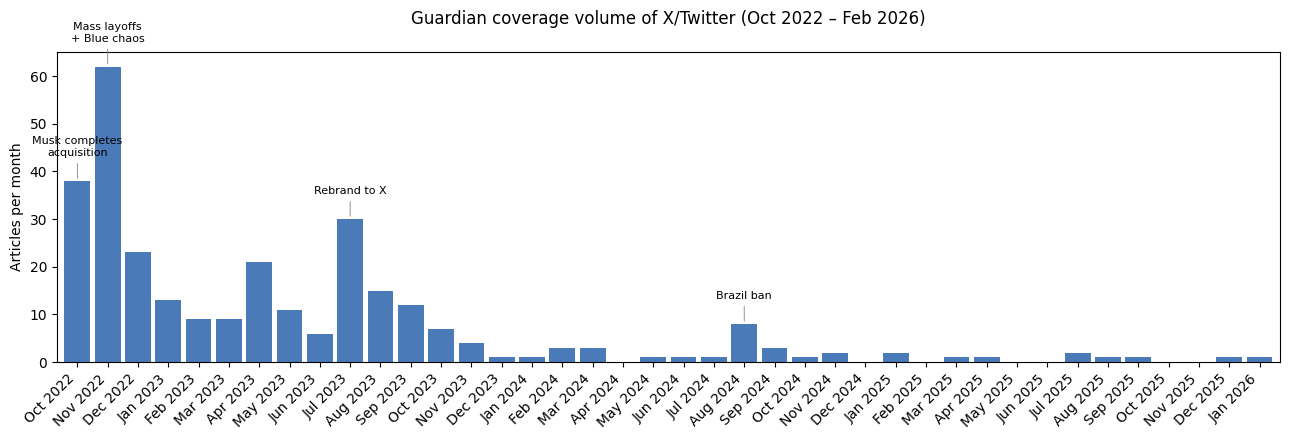


Total: 295 articles | Mean: 7.4/month | Peak: 62 (Nov 2022)


In [10]:
# =============================================================
# COVERAGE TIMELINE
# =============================================================
monthly = df.set_index("date").resample("ME").size()

fig, ax = plt.subplots(figsize=(13, 4.5))
monthly.plot(kind="bar", ax=ax, color="#4a7ab8", width=0.85)

events = {
    "2022-10-31": "Musk completes\nacquisition",
    "2022-11-30": "Mass layoffs\n+ Blue chaos",
    "2023-07-31": "Rebrand to X",
    "2024-08-31": "Brazil ban",
}

for date_str, label in events.items():
    try:
        idx = monthly.index.get_loc(pd.Timestamp(date_str, tz="UTC"))
        ax.annotate(label,
                    xy=(idx, monthly.iloc[idx]),
                    xytext=(0, 18), textcoords="offset points",
                    ha="center", fontsize=8,
                    arrowprops=dict(arrowstyle="-", color="gray", lw=0.6))
    except KeyError:
        pass

ax.set_title("Guardian coverage volume of X/Twitter (Oct 2022 – Feb 2026)",
             fontsize=12, pad=20)
ax.set_xlabel("")
ax.set_ylabel("Articles per month")
ax.set_xticklabels([d.strftime("%b %Y") for d in monthly.index],
                   rotation=45, ha="right")
plt.tight_layout()
plt.savefig("coverage_volume.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal: {len(df)} articles | "
      f"Mean: {monthly.mean():.1f}/month | "
      f"Peak: {monthly.max()} (Nov 2022)")

In [11]:
# =============================================================
# DATE FORMATTING FOR TIME-BASED ANALYSIS
# =============================================================

# Convert the 'date' column to proper datetime format
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Create a new 'month' column in YYYY-MM format (e.g., 2024-03)
df["month"] = df["date"].dt.to_period("M").astype(str)

# Preview the result
display(df[["date", "month", "headline"]].head(10))

/tmp/ipykernel_763/4193104735.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["date"].dt.to_period("M").astype(str)


,date,month,headline
0,2022-10-01 11:54:11+00:00,2022-10,Elon Musk and Twitter boss’s messages show how...
1,2022-10-04 19:42:44+00:00,2022-10,Elon Musk to proceed with $44bn buyout of Twit...
2,2022-10-05 00:43:10+00:00,2022-10,Musk’s Twitter deal is his least bad option – ...
3,2022-10-05 19:42:16+00:00,2022-10,Twitter’s board deserves credit for Elon Musk’...
4,2022-10-05 22:23:10+00:00,2022-10,Twitter v Musk trial still on as neither side ...
5,2022-10-06 10:00:33+00:00,2022-10,Disinformation in Spanish is prolific on Faceb...
6,2022-10-06 11:04:14+00:00,2022-10,Twitter v Elon Musk: what happens next in the ...
7,2022-10-06 21:46:14+00:00,2022-10,Twitter demands day in court after Elon Musk a...
8,2022-10-06 22:21:35+00:00,2022-10,Judge halts Elon Musk-Twitter litigation to al...
9,2022-10-07 10:56:33+00:00,2022-10,What happens now that Twitter v Elon Musk tria...


In [12]:
# =============================================================
# COUNT ARTICLES BY MONTH
# Transforms unstructured text data into a measurable business signal
# =============================================================

# Group articles by month and count how many fall into each
monthly_counts = (
    df.groupby("month")
      .size()
      .reset_index(name="article_count")
)

# Ensure the month column is a readable string (for plotting later)
monthly_counts["month"] = monthly_counts["month"].astype(str)

# Preview the result
display(monthly_counts)

# Quick summary for the write-up
print(f"\nMonths covered: {len(monthly_counts)}")
print(f"Total articles: {monthly_counts['article_count'].sum()}")
print(f"Peak month: {monthly_counts.loc[monthly_counts['article_count'].idxmax(), 'month']} "
      f"({monthly_counts['article_count'].max()} articles)")
print(f"Average per month: {monthly_counts['article_count'].mean():.1f}")

,month,article_count
0,2022-10,38
1,2022-11,62
2,2022-12,23
3,2023-01,13
4,2023-02,9
5,2023-03,9
6,2023-04,21
7,2023-05,11
8,2023-06,6
9,2023-07,30



Months covered: 33
Total articles: 295
Peak month: 2022-11 (62 articles)
Average per month: 8.9


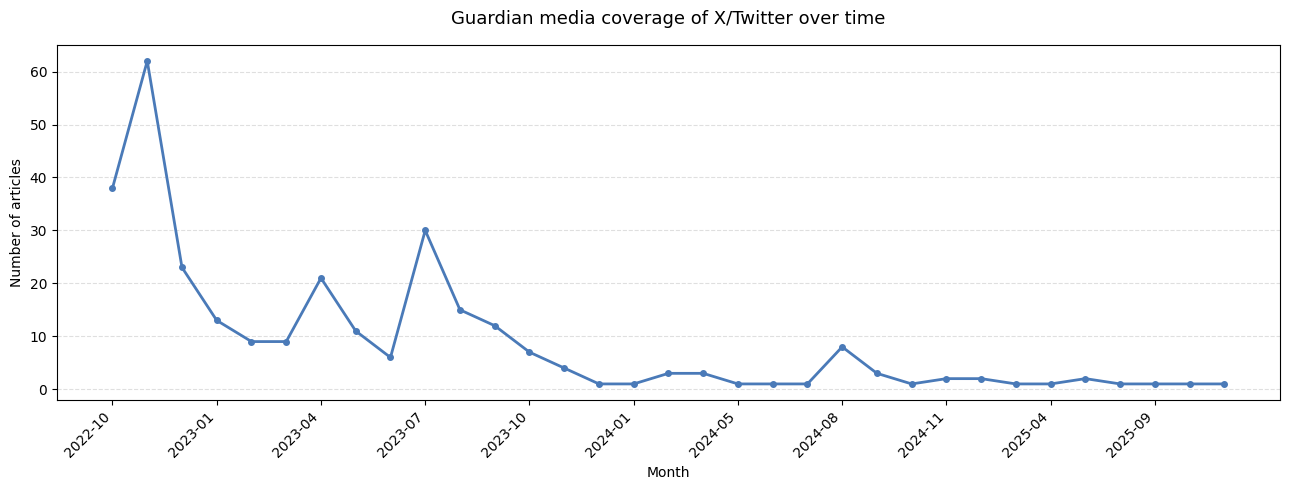

In [13]:
# =============================================================
# STEP 6 — VISUALISE THE TREND OVER TIME
# Turn monthly counts into a line chart to reveal patterns
# =============================================================

fig, ax = plt.subplots(figsize=(13, 5))

# Plot time (months) on the x-axis, article count on the y-axis
ax.plot(
    monthly_counts["month"],
    monthly_counts["article_count"],
    color="#4a7ab8",
    linewidth=2,
    marker="o",
    markersize=4,
)

# Labels and title
ax.set_title(
    "Guardian media coverage of X/Twitter over time",
    fontsize=13, pad=15,
)
ax.set_xlabel("Month")
ax.set_ylabel("Number of articles")

# Show every 3rd month label so the x-axis isn't crowded
ax.set_xticks(range(0, len(monthly_counts), 3))
ax.set_xticklabels(monthly_counts["month"][::3], rotation=45, ha="right")

# Light gridlines help read values off the chart
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("coverage_trend.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# =============================================================
# SECTION 4 — SETUP: Authenticate Gemini & load clean dataset
# =============================================================

# Install the Google GenAI SDK (quiet install)
!pip install -q -U google-genai

import pandas as pd
from google import genai
from google.colab import userdata

# -----------------------
# 1. Authenticate Gemini
# -----------------------
# Pulls the API key from Colab Secrets — never hard-code it.
GOOGLE_API_KEY = userdata.get("Gemini_API_Key")

if not GOOGLE_API_KEY:
    raise RuntimeError(
        "GOOGLE_API_KEY not found. Add it via the 🔑 Secrets panel "
        "in the left sidebar and enable notebook access."
    )

client = genai.Client(api_key=GOOGLE_API_KEY)
print("✓ Gemini client authenticated")

# -----------------------
# 2. Sanity-check the connection
# -----------------------
test = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="Reply with exactly: connection OK",
)
print(f"✓ API responded: {test.text.strip()}")

# -----------------------
# 3. Load the clean Guardian dataset
# -----------------------
df = pd.read_csv("guardian_x_clean.csv", parse_dates=["date"])
print(f"\n✓ Loaded {len(df)} clean Guardian articles")
print(f"   Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"   Sections:   {dict(df['section'].value_counts())}")

✓ Gemini client authenticated
✓ API responded: connection OK

✓ Loaded 295 clean Guardian articles
   Date range: 2022-10-01 → 2026-01-15
   Sections:   {'Technology': np.int64(268), 'Media': np.int64(18), 'Business': np.int64(9)}


In [15]:
# =============================================================
# PREPARE TEXTS FOR GEMINI ANALYSIS
# Builds a clean, labelled prompt input for each article.
# =============================================================

def prepare_article_text(row, body_char_limit=2500):
    """
    Format a single article into a labelled block for Gemini.
    Truncates body text to keep prompts efficient and cost-controlled.
    """
    headline = row.get("headline", "") or ""
    trail    = row.get("trail_text", "") or ""
    body     = row.get("body_text", "") or ""

    # Truncate body — first ~2,500 chars cover most articles' key content
    body_truncated = body[:body_char_limit]
    if len(body) > body_char_limit:
        body_truncated += " [...]"

    return (
        f"Date: {row['date'].strftime('%Y-%m-%d')}\n"
        f"Section: {row.get('section', '')}\n"
        f"Headline: {headline}\n"
        f"Summary: {trail}\n"
        f"Article body: {body_truncated}"
    )

# Apply to every row, skipping any with missing body text
df["prompt_text"] = df.apply(
    lambda row: prepare_article_text(row) if pd.notna(row.get("body_text")) else None,
    axis=1,
)

# Drop any rows where preparation failed
before = len(df)
df = df.dropna(subset=["prompt_text"]).reset_index(drop=True)
print(f"Prepared {len(df)} articles ({before - len(df)} dropped for missing body text)")

# Inspect one prepared example
print("\n--- Example prepared text (first 800 chars) ---")
print(df.iloc[0]["prompt_text"][:800])

Prepared 295 articles (0 dropped for missing body text)

--- Example prepared text (first 800 chars) ---
Date: 2022-10-01
Section: Technology
Headline: Elon Musk and Twitter boss’s messages show how pair fell out 
Summary: Texts disclosed to a US court show the two bonding before the Tesla CEO tweeted: ‘Is Twitter dying?’
Article body: Newly published messages between Elon Musk and the CEO of Twitter, Parag Agrawal, show that their relationship appeared to be blossoming before it dramatically soured, with the Tesla boss tweeting: “Is Twitter dying?” The series of text messages, disclosed in a Delaware court filing, suggest that the two men were for a short period bonding, including over their shared love of engineering, after Agrawal got in touch with him, weeks before Musk revealed his offer to buy Twitter. The communications give an insight into the careful negotiations that were privately 


In [20]:
import os
os.remove("gemini_analysis.csv")
print("Cleared broken results file — ready to rerun analysis loop")

Cleared broken results file — ready to rerun analysis loop


In [21]:
# =============================================================
# PASS 1 — HARDENED VERSION
# Fails loudly on first error rather than silently filling Nones.
# =============================================================
import json, time, os
from google.genai import types
from tqdm import tqdm

SYSTEM_INSTRUCTION = """You are a senior media intelligence analyst evaluating Guardian coverage of X (formerly Twitter) since Elon Musk's October 2022 acquisition.

Return a JSON object with these exact fields:

- sentiment: one of [very_negative, negative, neutral, positive, very_positive]
- sentiment_rationale: ONE sentence explaining the score
- primary_theme: ONE of [acquisition, layoffs, content_moderation, advertiser_relations,
  rebrand_strategy, regulation_legal, leadership, platform_competition,
  misinformation, financial_performance, user_experience, other]
- driver_event: specific event in 5 words or fewer, or null
- stance_toward_company: one of [critical, neutral, sympathetic]

Score the article's portrayal of X/Twitter as a company or platform, not Musk personally unless he is the subject AS owner.

Return ONLY valid JSON. No prose, no markdown."""

def analyse_article(prompt_text):
    """No retries, no try/except — fail loud during testing."""
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt_text,
        config=types.GenerateContentConfig(
            system_instruction=SYSTEM_INSTRUCTION,
            response_mime_type="application/json",
            temperature=0,
        ),
    )
    return json.loads(response.text)

# ---- Test on first 3 articles BEFORE running the full loop ----
print("--- Testing on 3 articles ---")
for i in range(3):
    result = analyse_article(df.iloc[i]["prompt_text"])
    print(f"\nArticle {i}: {df.iloc[i]['headline'][:70]}")
    print(f"  sentiment: {result['sentiment']}")
    print(f"  theme: {result['primary_theme']}")
    print(f"  driver: {result['driver_event']}")

print("\n✓ Test passed. Ready to run full loop.")

--- Testing on 3 articles ---

Article 0: Elon Musk and Twitter boss’s messages show how pair fell out 
  sentiment: negative
  theme: acquisition
  driver: Musk-Agrawal messages disclosed

Article 1: Elon Musk to proceed with $44bn buyout of Twitter after U-turn
  sentiment: neutral
  theme: acquisition
  driver: Musk's U-turn on acquisition

Article 2: Musk’s Twitter deal is his least bad option – but he must repair the d
  sentiment: negative
  theme: acquisition
  driver: Musk proceeds with deal

✓ Test passed. Ready to run full loop.


In [22]:
import os
if os.path.exists("gemini_analysis.csv"):
    os.remove("gemini_analysis.csv")
    print("✓ Cleared broken gemini_analysis.csv — ready to rerun analysis")
else:
    print("File doesn't exist yet — fine to proceed")

File doesn't exist yet — fine to proceed


In [23]:
# =============================================================
# PASS 1 — FULL ANALYSIS LOOP
# Same prompt that just passed the 3-article test, applied to all rows.
# =============================================================
import json, time, os
from google.genai import types
from tqdm import tqdm

SYSTEM_INSTRUCTION = """You are a senior media intelligence analyst evaluating Guardian coverage of X (formerly Twitter) since Elon Musk's October 2022 acquisition.

Return a JSON object with these exact fields:

- sentiment: one of [very_negative, negative, neutral, positive, very_positive]
- sentiment_rationale: ONE sentence explaining the score
- primary_theme: ONE of [acquisition, layoffs, content_moderation, advertiser_relations,
  rebrand_strategy, regulation_legal, leadership, platform_competition,
  misinformation, financial_performance, user_experience, other]
- driver_event: specific event in 5 words or fewer, or null
- stance_toward_company: one of [critical, neutral, sympathetic]

Score the article's portrayal of X/Twitter as a company or platform, not Musk personally unless he is the subject AS owner.

Return ONLY valid JSON. No prose, no markdown."""

def analyse_article(prompt_text, max_retries=3):
    """Send one article to Gemini with light retry logic for transient errors."""
    for attempt in range(max_retries):
        try:
            response = client.models.generate_content(
                model="gemini-2.5-flash",
                contents=prompt_text,
                config=types.GenerateContentConfig(
                    system_instruction=SYSTEM_INSTRUCTION,
                    response_mime_type="application/json",
                    temperature=0,
                ),
            )
            return json.loads(response.text), None
        except Exception as e:
            if attempt == max_retries - 1:
                return None, str(e)
            time.sleep(2 ** attempt)

# -----------------------
# Resume-friendly setup
# -----------------------
RESULTS_FILE = "gemini_analysis.csv"

if os.path.exists(RESULTS_FILE):
    results_df = pd.read_csv(RESULTS_FILE)
    # Only count rows that actually have a sentiment as 'done'
    done_ids = set(results_df.dropna(subset=["sentiment"])["id"].tolist())
    print(f"Resuming — {len(done_ids)} valid records already on disk")
else:
    results_df = pd.DataFrame()
    done_ids = set()

to_process = df[~df["id"].isin(done_ids)].reset_index(drop=True)
print(f"To analyse: {len(to_process)} articles\n")

# -----------------------
# Run the loop
# -----------------------
new_rows = []
errors = []
SAVE_EVERY = 25

for i, row in tqdm(to_process.iterrows(), total=len(to_process), desc="Analysing"):
    result, error = analyse_article(row["prompt_text"])

    record = {
        "id":       row["id"],
        "date":     row["date"],
        "section":  row["section"],
        "headline": row["headline"],
        "url":      row["url"],
    }

    if result:
        record.update(result)
    else:
        errors.append({"id": row["id"], "headline": row["headline"], "error": error})
        record.update({
            "sentiment": None, "sentiment_rationale": None,
            "primary_theme": None, "driver_event": None,
            "stance_toward_company": None,
        })

    new_rows.append(record)

    # Periodic checkpoint
    if (i + 1) % SAVE_EVERY == 0:
        partial = pd.concat([results_df, pd.DataFrame(new_rows)], ignore_index=True)
        partial.to_csv(RESULTS_FILE, index=False)

# -----------------------
# Final save
# -----------------------
results_df = pd.concat([results_df, pd.DataFrame(new_rows)], ignore_index=True)
results_df["date"] = pd.to_datetime(results_df["date"], errors="coerce")
results_df.to_csv(RESULTS_FILE, index=False)

# -----------------------
# Summary
# -----------------------
print(f"\n✓ Total records: {len(results_df)}")
print(f"✓ Successfully analysed: {results_df['sentiment'].notna().sum()}")
print(f"✗ Failed: {results_df['sentiment'].isna().sum()}")

if errors:
    print(f"\nFirst 3 errors:")
    for e in errors[:3]:
        print(f"  - {e['headline'][:60]}: {e['error'][:100]}")

print("\n--- Sentiment distribution ---")
print(results_df["sentiment"].value_counts())

print("\n--- Top themes ---")
print(results_df["primary_theme"].value_counts().head(8))

print("\n--- Sample results ---")
display(results_df.dropna(subset=["sentiment"])
                  [["date", "headline", "sentiment", "primary_theme", "driver_event"]]
                  .sample(min(5, results_df["sentiment"].notna().sum()), random_state=42))

To analyse: 295 articles



Analysing: 100%|██████████| 295/295 [13:25<00:00,  2.73s/it]


✓ Total records: 295
✓ Successfully analysed: 295
✗ Failed: 0

--- Sentiment distribution ---
sentiment
negative         184
very_negative     90
neutral           17
positive           4
Name: count, dtype: int64

--- Top themes ---
primary_theme
content_moderation       68
acquisition              40
layoffs                  32
rebrand_strategy         28
user_experience          24
platform_competition     24
financial_performance    22
regulation_legal         17
Name: count, dtype: int64

--- Sample results ---


,date,headline,sentiment,primary_theme,driver_event
273,2024-08-12 13:01:25+00:00,Elon Musk should face arrest if he incited UK ...,very_negative,misinformation,UK riots after Southport stabbing
155,2023-04-04 10:45:38+00:00,TechScape: Elon Musk promised to take away the...,negative,financial_performance,Failed blue tick removal
84,2022-11-19 15:37:57+00:00,Twitter has ‘50% chance’ of major crash during...,negative,layoffs,World Cup traffic spikes
82,2022-11-18 11:39:37+00:00,"Twitter may not cope with World Cup abuse, say...",negative,content_moderation,trust and safety layoffs
261,2024-01-02 14:24:46+00:00,Value of X has fallen 71% since purchase by Mu...,very_negative,financial_performance,Fidelity marks down X value


In [24]:
# Worth eyeballing — what gets positive coverage?
positive_articles = (results_df.query("sentiment in ['positive', 'very_positive']")
                               [["date", "headline", "primary_theme", "driver_event",
                                 "sentiment_rationale"]])
display(positive_articles)

,date,headline,primary_theme,driver_event,sentiment_rationale
3,2022-10-05 19:42:16+00:00,Twitter’s board deserves credit for Elon Musk’...,acquisition,Musk's acquisition U-turn,The article praises Twitter's board for succes...
29,2022-10-29 17:08:04+00:00,From Ed Balls to BTS: the greatest hits in Twi...,user_experience,Musk's acquisition,The article celebrates Twitter's historical im...
89,2022-11-21 19:42:22+00:00,Elon Musk rules out conspiracy theorist Alex J...,content_moderation,Musk rules out Alex Jones's return,The article reports Elon Musk's decision to pe...
189,2023-06-12 15:21:13+00:00,Tucker Carlson ‘will not be silenced’ as Fox N...,content_moderation,Tucker Carlson's Twitter show debut,The article highlights Twitter as a platform e...


In [25]:
# =============================================================
# SECTION 4 — PASS 2: SYNTHESIS & EXECUTIVE SUMMARY
# Aggregates Pass 1 results, asks Gemini to interpret patterns.
# Run this AFTER gemini_analysis.csv has been generated.
# =============================================================

import pandas as pd
from google.genai import types

# -----------------------
# 1. Load and aggregate Pass 1 results
# -----------------------
results = pd.read_csv("gemini_analysis.csv", parse_dates=["date"])
results = results.dropna(subset=["sentiment"]).copy()   # drop any failed rows

# Map sentiment labels to numeric scores for trend calculation
sentiment_score_map = {
    "very_negative": -2, "negative": -1, "neutral": 0,
    "positive": 1, "very_positive": 2,
}
results["sentiment_score"] = results["sentiment"].map(sentiment_score_map)
results["month"] = results["date"].dt.to_period("M").astype(str)

# Build the structured summary table that Pass 2 will analyse
monthly_summary = (
    results.groupby("month")
           .agg(
               article_count    = ("id", "count"),
               avg_sentiment    = ("sentiment_score", "mean"),
               very_negative    = ("sentiment", lambda s: (s == "very_negative").sum()),
               negative         = ("sentiment", lambda s: (s == "negative").sum()),
               neutral          = ("sentiment", lambda s: (s == "neutral").sum()),
               positive         = ("sentiment", lambda s: (s == "positive").sum()),
               very_positive    = ("sentiment", lambda s: (s == "very_positive").sum()),
               top_themes       = ("primary_theme",
                                   lambda s: ", ".join(s.value_counts().head(3).index.tolist())),
               top_drivers      = ("driver_event",
                                   lambda s: ", ".join(s.dropna().value_counts().head(3).index.tolist())),
           )
           .reset_index()
)

monthly_summary["avg_sentiment"] = monthly_summary["avg_sentiment"].round(2)

print(f"Aggregated {len(results)} articles into {len(monthly_summary)} months")
display(monthly_summary.head(10))

# -----------------------
# 2. Build the synthesis prompt
# -----------------------
# Convert the monthly table to a compact, readable string for the model
summary_table_text = monthly_summary.to_string(index=False)

SYNTHESIS_PROMPT = f"""You are a senior media intelligence consultant analysing how Guardian newspaper coverage of X (formerly Twitter) has evolved since Elon Musk's October 2022 acquisition.

Below is a monthly summary of {len(results)} articles. Sentiment scores range from -2 (very negative) to +2 (very positive). Use ONLY the data provided — do not invent figures.

DATA:
{summary_table_text}

Answer the following research question, in the exact structure shown.

RESEARCH QUESTION:
How has the media perception of X (formerly Twitter) evolved over time, and what are the key drivers behind this change?

REQUIRED OUTPUT FORMAT (use these exact headings):

## 1. Overall sentiment evolution over time
- 4-6 bullet points
- Cite specific months and average sentiment scores from the data
- Identify distinct phases (e.g. acute crisis, transition, post-rebrand)

## 2. Significant spikes and drops in sentiment
- 3-5 bullet points
- Each bullet must name: the month, the direction of the shift, the magnitude (numeric), and the likely driver event from the data
- Reference top_drivers and top_themes columns to justify causation

## 3. Executive summary (max 120 words)
- Single paragraph, no bullets
- Written for a board-level audience
- Explain what the trajectory suggests about X's reputational position and strategic situation
- Strictly under 120 words

Return your answer in clean Markdown using the exact headings above."""

# -----------------------
# 3. Send to Gemini
# -----------------------
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=SYNTHESIS_PROMPT,
    config=types.GenerateContentConfig(
        temperature=0.2,    # slight creativity for narrative quality, still highly stable
    ),
)

executive_analysis = response.text

# -----------------------
# 4. Display and save
# -----------------------
print("\n" + "=" * 70)
print("EXECUTIVE ANALYSIS")
print("=" * 70 + "\n")
print(executive_analysis)

# Save the narrative to a file for inclusion in your write-up
with open("executive_analysis.md", "w") as f:
    f.write(executive_analysis)

monthly_summary.to_csv("monthly_summary.csv", index=False)

print("\n✓ Saved: executive_analysis.md")
print("✓ Saved: monthly_summary.csv")

/tmp/ipykernel_763/3943664623.py:22: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  results["month"] = results["date"].dt.to_period("M").astype(str)


Aggregated 295 articles into 33 months


,month,article_count,avg_sentiment,very_negative,negative,neutral,positive,very_positive,top_themes,top_drivers
0,2022-10,38,-0.87,6,23,7,2,0,"acquisition, content_moderation, layoffs","Musk's Twitter acquisition, Musk's acquisition..."
1,2022-11,62,-1.31,24,34,3,1,0,"layoffs, content_moderation, acquisition","mass layoffs, Musk's acquisition of Twitter, M..."
2,2022-12,23,-1.43,10,13,0,0,0,"content_moderation, leadership, user_experience","Musk's poll to step down, Apple row resolution..."
3,2023-01,13,-1.31,4,9,0,0,0,"financial_performance, layoffs, advertiser_rel...","Andrew Tate's arrest, advertisers paused spend..."
4,2023-02,9,-1.22,2,7,0,0,0,"content_moderation, user_experience, financial...","Twitter Files release, platform outage, Musk's..."
5,2023-03,9,-1.33,3,6,0,0,0,"user_experience, regulation_legal, layoffs","global site outage, Frequent site outages, SVB..."
6,2023-04,21,-1.10,3,17,1,0,0,"rebrand_strategy, financial_performance, conte...","blue tick non-removal, Failed blue tick remova..."
7,2023-05,11,-1.36,5,5,1,0,0,"content_moderation, financial_performance, use...","Linda Yaccarino appointed CEO, Circles privacy..."
8,2023-06,6,-0.83,1,4,0,1,0,"regulation_legal, misinformation, platform_com...","Twitter quits EU voluntary code, Tucker Carlso..."
9,2023-07,30,-1.13,6,22,2,0,0,"platform_competition, rebrand_strategy, user_e...","Threads launch, Threads app launch, Twitter re..."



EXECUTIVE ANALYSIS

## 1. Overall sentiment evolution over time
*   The initial period following Elon Musk's acquisition in October 2022 saw a rapid decline in media perception, with average sentiment dropping from -0.87 (38 articles) to a low of -1.43 by December 2022 (23 articles), driven by themes of layoffs and content moderation. This marks an acute crisis phase.
*   Throughout 2023, sentiment remained predominantly negative, fluctuating between -0.83 (June 2023, 6 articles) and -1.43 (October 2023, 7 articles), with the rebrand to X and the launch of Threads contributing to a dip in July 2023 (-1.13, 30 articles). This represents a turbulent transition phase.
*   From late 2023 into 2026, coverage became significantly sparser, often featuring only 1-4 articles per month, yet sentiment frequently plunged to its lowest possible score of -2.00 (e.g., November 2023, January 2024, March 2025, July 2025, September 2025, October 2024).
*   Despite the overall negative trend, there were

In [26]:
# =============================================================
# SECTION 4 — PASS 3: DRIVERS OF PERCEPTION CHANGE
# Identifies events, entities, and external factors driving shifts.
# Run after Pass 1 (gemini_analysis.csv) is complete.
# =============================================================

import pandas as pd
from google.genai import types

# -----------------------
# 1. Load and aggregate Pass 1 results
# -----------------------
results = pd.read_csv("gemini_analysis.csv", parse_dates=["date"])
results = results.dropna(subset=["sentiment"]).copy()

# Numeric sentiment for shift detection
sentiment_score_map = {
    "very_negative": -2, "negative": -1, "neutral": 0,
    "positive": 1, "very_positive": 2,
}
results["sentiment_score"] = results["sentiment"].map(sentiment_score_map)
results["month"] = results["date"].dt.to_period("M").astype(str)

# Monthly aggregate
monthly = (
    results.groupby("month")
           .agg(
               article_count = ("id", "count"),
               avg_sentiment = ("sentiment_score", "mean"),
               top_themes    = ("primary_theme",
                                lambda s: ", ".join(s.value_counts().head(3).index.tolist())),
               top_drivers   = ("driver_event",
                                lambda s: ", ".join(s.dropna().value_counts().head(5).index.tolist())),
           )
           .reset_index()
)
monthly["avg_sentiment"] = monthly["avg_sentiment"].round(2)

# Detect month-on-month sentiment shifts (the 'changes' Pass 3 asks about)
monthly["sentiment_change"] = monthly["avg_sentiment"].diff().round(2)

# -----------------------
# 2. Top drivers across the whole dataset
# -----------------------
top_drivers_overall = (results["driver_event"]
                       .dropna()
                       .value_counts()
                       .head(15)
                       .reset_index())
top_drivers_overall.columns = ["driver_event", "article_count"]

# -----------------------
# 3. Build the synthesis prompt
# -----------------------
monthly_text  = monthly.to_string(index=False)
drivers_text  = top_drivers_overall.to_string(index=False)

DRIVERS_PROMPT = f"""You are a senior media intelligence consultant analysing the Guardian's coverage of X (formerly Twitter) since Elon Musk's October 2022 acquisition.

You are given two structured tables built from {len(results)} classified Guardian articles. Sentiment scores range from -2 (very negative) to +2 (very positive). Use ONLY the data provided — do not invent figures or events not present in the data.

TABLE A — MONTHLY SUMMARY (with month-on-month sentiment changes):
{monthly_text}

TABLE B — TOP 15 DRIVER EVENTS ACROSS THE WHOLE DATASET:
{drivers_text}

RESEARCH QUESTION:
What are the key drivers behind changes in media perception of X?

REQUIRED OUTPUT FORMAT — use these exact headings, all bullet points:

## 1. Specific events, announcements, or incidents coinciding with major sentiment changes
- 4-6 bullets
- Each bullet must reference a specific month from Table A AND a driver event from Table A or B
- State the magnitude of the sentiment change (use the sentiment_change column)
- Explain how the driver plausibly caused the shift

## 2. Recurring entities, themes, or phrases visible during sentiment shifts
- 4-5 bullets
- Identify which themes (from top_themes column) and which named drivers (from top_drivers / Table B) appear most often during negative shifts
- Be specific: name executives (Musk, Yaccarino), regulators (EU, DSA, Ofcom), competitors (Bluesky, Threads, Mastodon), or recurring controversies as they appear in the data

## 3. External factors influencing perception
- 3-4 bullets
- Identify pressures from outside X itself: regulation (EU/DSA/UK), competitor launches, advertiser actions, real-world events that intersected with X (e.g. UK riots, Brazil court ruling, US elections)
- Distinguish these from internal-decision drivers
- Each bullet must cite an event or driver visible in Table A or B

## 4. Executive summary (max 120 words)
- Single paragraph, no bullets
- Strictly under 120 words
- Written for a board-level audience
- Summarise the type of drivers behind perception change (internal decisions vs external pressures, individual events vs sustained pressures), and what this implies strategically for X

Return your answer in clean Markdown using the exact headings above."""

# -----------------------
# 4. Send to Gemini
# -----------------------
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=DRIVERS_PROMPT,
    config=types.GenerateContentConfig(
        temperature=0.2,
    ),
)

drivers_analysis = response.text

# -----------------------
# 5. Display and save
# -----------------------
print("=" * 70)
print("DRIVERS OF PERCEPTION CHANGE — ANALYSIS")
print("=" * 70 + "\n")
print(drivers_analysis)

with open("drivers_analysis.md", "w") as f:
    f.write(drivers_analysis)

monthly.to_csv("monthly_summary_with_changes.csv", index=False)
top_drivers_overall.to_csv("top_drivers.csv", index=False)

print("\n✓ Saved: drivers_analysis.md")
print("✓ Saved: monthly_summary_with_changes.csv")
print("✓ Saved: top_drivers.csv")

/tmp/ipykernel_763/176780715.py:22: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  results["month"] = results["date"].dt.to_period("M").astype(str)


DRIVERS OF PERCEPTION CHANGE — ANALYSIS

## 1. Specific events, announcements, or incidents coinciding with major sentiment changes

*   **November 2022:** A sentiment change of -0.44 (from -0.87 to -1.31) was driven by `mass layoffs` and `Musk's acquisition of Twitter`. The widespread job cuts immediately following Musk's takeover likely fueled negative media perception regarding the company's stability and ethical practices.
*   **July 2023:** A sentiment change of -0.30 (from -0.83 to -1.13) coincided with `Threads launch`, `Twitter rebrands to X`, and `tweet viewing limits imposed`. The introduction of a direct competitor (Threads), coupled with the controversial rebrand and unpopular user restrictions, significantly contributed to negative sentiment.
*   **November 2023:** A sharp sentiment decline of -0.57 (from -1.43 to -2.00) was primarily driven by `Musk endorses antisemitic tweet` and `Musk's antisemitic tweets`. Elon Musk's personal endorsement of antisemitic content directl

/tmp/ipykernel_763/993989064.py:22: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  results["month"]    = results["date"].dt.to_period("M").astype(str)


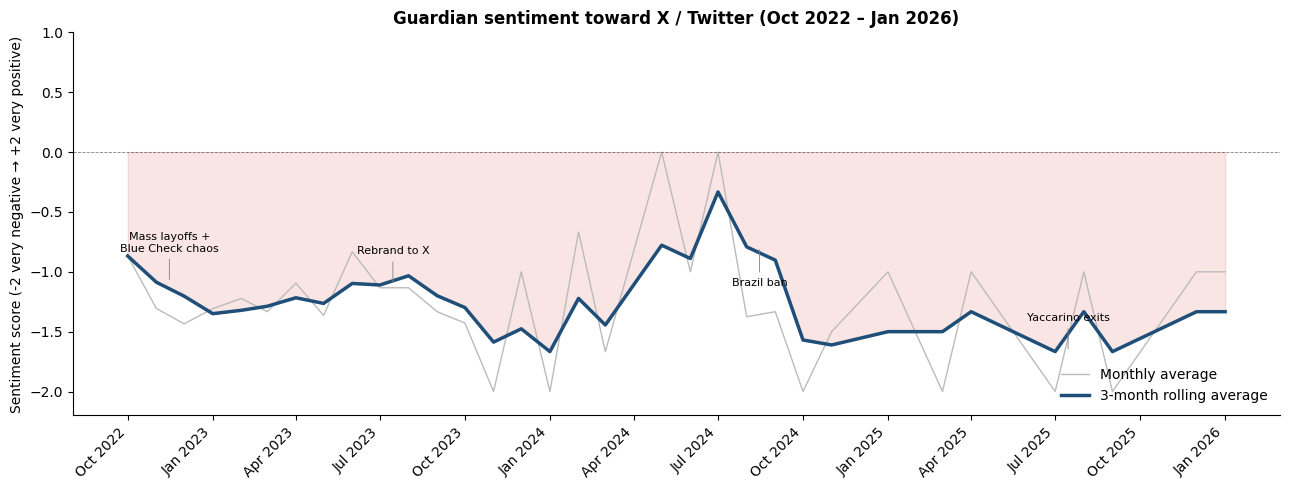

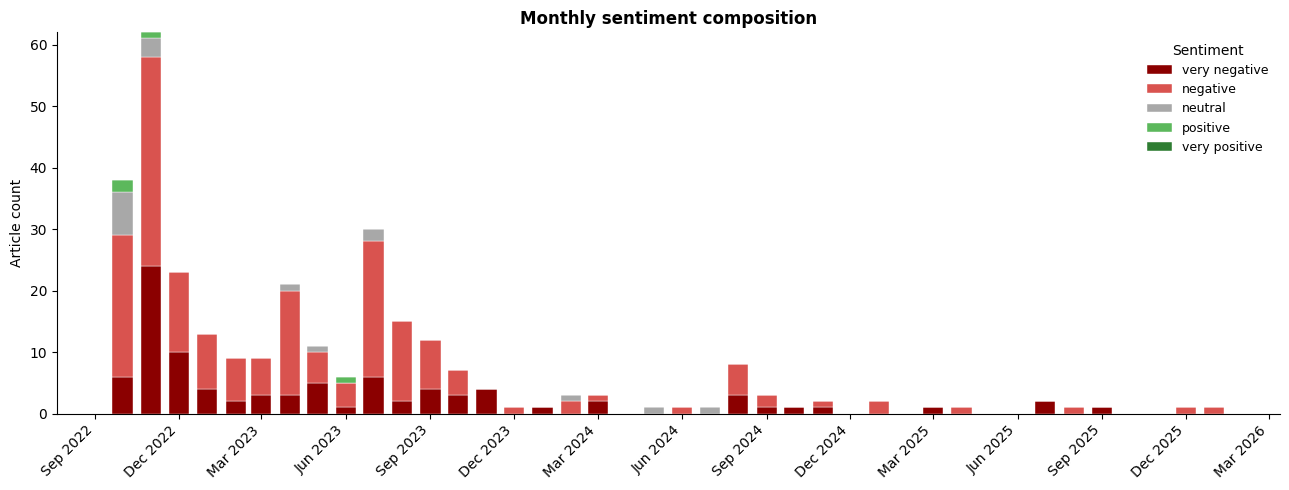

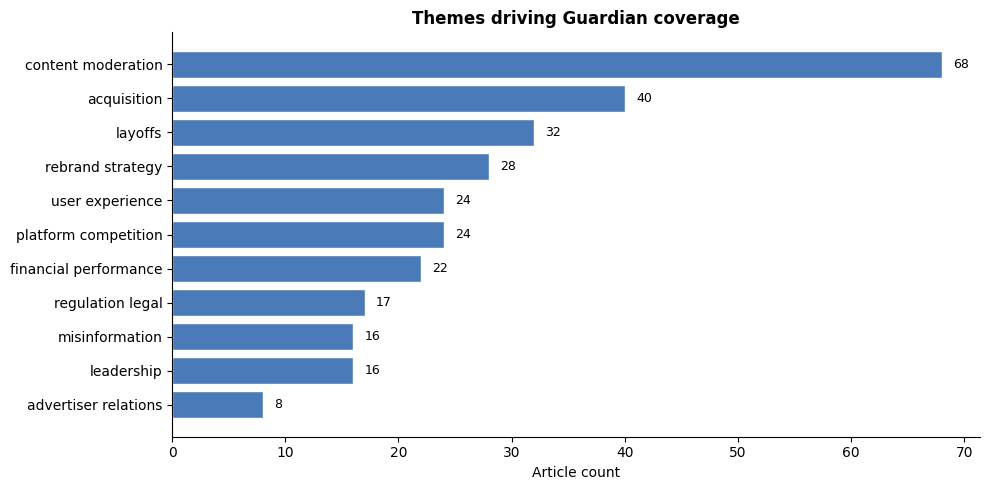

/tmp/ipykernel_763/993989064.py:158: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  results["quarter"] = results["date"].dt.to_period("Q").astype(str)


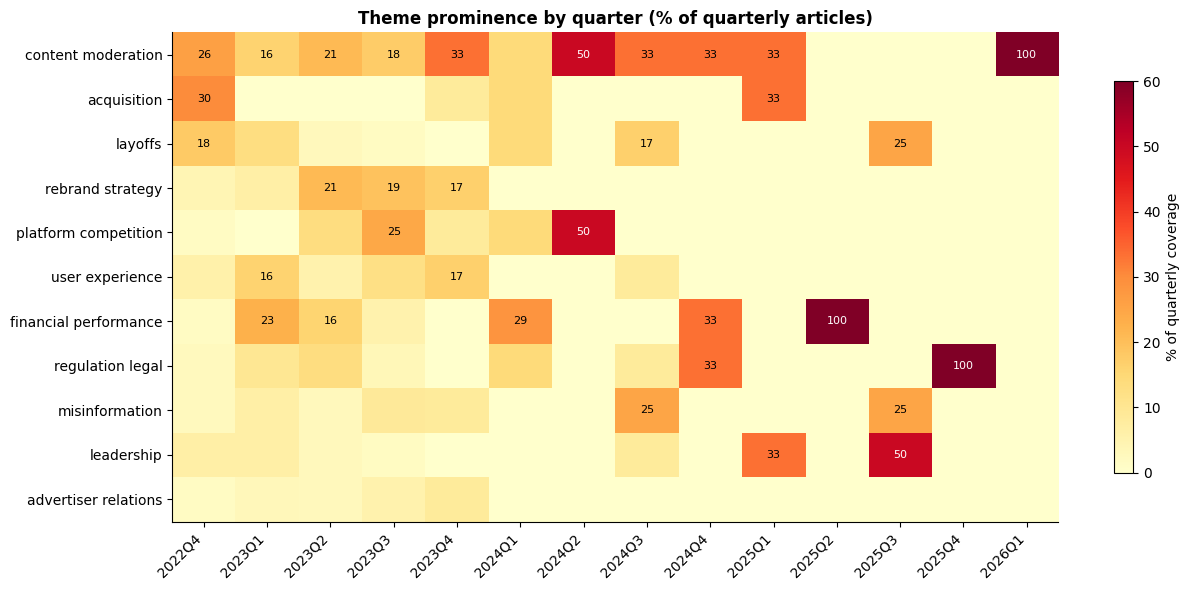

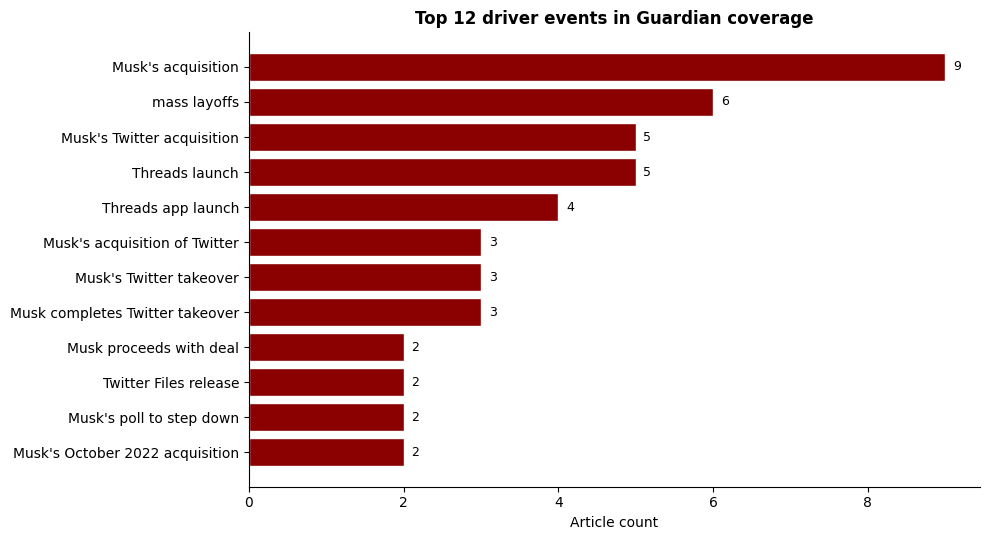


✓ All 5 charts saved as PNGs (01_… through 05_…)
These can be inserted directly into your report.


In [28]:
# =============================================================
# SECTION 4 — VISUALISATIONS
# Five charts that answer the assignment's analytical questions.
# =============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# -----------------------
# Load and prep
# -----------------------
results = pd.read_csv("gemini_analysis.csv", parse_dates=["date"])
results = results.dropna(subset=["sentiment"]).copy()

sentiment_score_map = {
    "very_negative": -2, "negative": -1, "neutral": 0,
    "positive": 1, "very_positive": 2,
}
results["sentiment_score"] = results["sentiment"].map(sentiment_score_map)
results["month"]    = results["date"].dt.to_period("M").astype(str)
results["month_dt"] = pd.to_datetime(results["month"])

# Consistent palette
COLOURS = {
    "very_negative": "#8B0000",
    "negative":      "#D9534F",
    "neutral":       "#A8A8A8",
    "positive":      "#5CB85C",
    "very_positive": "#2E7D32",
}
ORDER = ["very_negative", "negative", "neutral", "positive", "very_positive"]

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# =============================================================
# CHART 1 — Monthly average sentiment with rolling trend
# Question: How has sentiment evolved over time?
# Goes in: Section 4 (analysis), referenced in Section 5
# =============================================================
monthly_avg = (results.groupby("month_dt")["sentiment_score"]
                      .mean()
                      .reset_index()
                      .sort_values("month_dt"))
monthly_avg["rolling_3m"] = monthly_avg["sentiment_score"].rolling(3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 5))

# Faint monthly line for noise
ax.plot(monthly_avg["month_dt"], monthly_avg["sentiment_score"],
        color="#bbbbbb", linewidth=1, label="Monthly average")
# Bold rolling line for the actual trend
ax.plot(monthly_avg["month_dt"], monthly_avg["rolling_3m"],
        color="#1f4e79", linewidth=2.5, label="3-month rolling average")

ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)
ax.fill_between(monthly_avg["month_dt"], monthly_avg["rolling_3m"], 0,
                where=(monthly_avg["rolling_3m"] < 0),
                color="#D9534F", alpha=0.15)

# Annotate key events
events = {
    "2022-11-15": ("Mass layoffs +\nBlue Check chaos", "top"),
    "2023-07-15": ("Rebrand to X", "top"),
    "2024-08-15": ("Brazil ban", "bottom"),
    "2025-07-15": ("Yaccarino exits", "top"),
}
for date_str, (label, pos) in events.items():
    d = pd.Timestamp(date_str)
    if d >= monthly_avg["month_dt"].min() and d <= monthly_avg["month_dt"].max():
        y = monthly_avg.loc[(monthly_avg["month_dt"] - d).abs().idxmin(), "rolling_3m"]
        offset = 22 if pos == "top" else -28
        ax.annotate(label, xy=(d, y), xytext=(0, offset),
                    textcoords="offset points", ha="center", fontsize=8,
                    arrowprops=dict(arrowstyle="-", color="gray", lw=0.6))

ax.set_title("Guardian sentiment toward X / Twitter (Oct 2022 – Jan 2026)")
ax.set_ylabel("Sentiment score (-2 very negative → +2 very positive)")
ax.set_xlabel("")
ax.set_ylim(-2.2, 1.0)
ax.legend(loc="lower right", frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig("01_sentiment_over_time.png", dpi=150, bbox_inches="tight")
plt.show()


# =============================================================
# CHART 2 — Stacked bar: sentiment composition by month
# Question: Was each month uniformly negative, or mixed?
# =============================================================
sentiment_counts = (results.groupby(["month_dt", "sentiment"])
                           .size()
                           .unstack(fill_value=0)
                           .reindex(columns=ORDER, fill_value=0)
                           .reset_index()
                           .sort_values("month_dt"))

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(sentiment_counts))
for s in ORDER:
    ax.bar(sentiment_counts["month_dt"], sentiment_counts[s],
           bottom=bottom, color=COLOURS[s],
           label=s.replace("_", " "), width=22, edgecolor="white", linewidth=0.3)
    bottom += sentiment_counts[s].values

ax.set_title("Monthly sentiment composition")
ax.set_ylabel("Article count")
ax.set_xlabel("")
ax.legend(title="Sentiment", loc="upper right", frameon=False, fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig("02_sentiment_composition.png", dpi=150, bbox_inches="tight")
plt.show()


# =============================================================
# CHART 3 — Theme frequency
# Question: What is the coverage about?
# =============================================================
theme_counts = (results["primary_theme"]
                .value_counts()
                .reset_index())
theme_counts.columns = ["theme", "count"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(theme_counts["theme"].str.replace("_", " "),
               theme_counts["count"],
               color="#4a7ab8", edgecolor="white")
ax.invert_yaxis()
ax.set_title("Themes driving Guardian coverage")
ax.set_xlabel("Article count")
for bar, count in zip(bars, theme_counts["count"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(count), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("03_theme_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


# =============================================================
# CHART 4 — Theme heatmap by quarter
# Question: How has the focus of coverage SHIFTED over time?
# This is the strongest Section 5 visual — it shows the story arc.
# =============================================================
results["quarter"] = results["date"].dt.to_period("Q").astype(str)

heatmap_data = (results.groupby(["quarter", "primary_theme"])
                       .size()
                       .unstack(fill_value=0))
# Normalise per quarter (% of that quarter's coverage)
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

# Order themes by total volume so the chart reads cleanly
theme_order = (heatmap_data.sum().sort_values(ascending=False).index.tolist())
heatmap_pct = heatmap_pct[theme_order]

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(heatmap_pct.T, aspect="auto", cmap="YlOrRd", vmin=0, vmax=60)

ax.set_xticks(range(len(heatmap_pct.index)))
ax.set_xticklabels(heatmap_pct.index, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_pct.columns)))
ax.set_yticklabels([t.replace("_", " ") for t in heatmap_pct.columns])
ax.set_title("Theme prominence by quarter (% of quarterly articles)")

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("% of quarterly coverage")

# Annotate cells with percentage where >= 15%
for i in range(heatmap_pct.shape[0]):
    for j in range(heatmap_pct.shape[1]):
        v = heatmap_pct.iloc[i, j]
        if v >= 15:
            ax.text(i, j, f"{v:.0f}", ha="center", va="center",
                    color="white" if v > 35 else "black", fontsize=8)

plt.tight_layout()
plt.savefig("04_theme_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


# =============================================================
# CHART 5 — Top driver events
# Question: WHICH SPECIFIC events drove the most coverage?
# =============================================================
top_drivers = (results["driver_event"]
               .dropna()
               .value_counts()
               .head(12)
               .reset_index())
top_drivers.columns = ["driver", "count"]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(top_drivers["driver"], top_drivers["count"],
               color="#8B0000", edgecolor="white")
ax.invert_yaxis()
ax.set_title("Top 12 driver events in Guardian coverage")
ax.set_xlabel("Article count")
for bar, count in zip(bars, top_drivers["count"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(count), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("05_top_drivers.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✓ All 5 charts saved as PNGs (01_… through 05_…)")
print("These can be inserted directly into your report.")

In [29]:
# =============================================================
# NORMALISE DRIVER EVENT LABELS
# Gemini produced multiple wordings for the same event — group them.
# =============================================================

import pandas as pd

results = pd.read_csv("gemini_analysis.csv", parse_dates=["date"])
results = results.dropna(subset=["sentiment"]).copy()

# Inspect what's there before normalising
print("--- Top 25 raw driver labels ---")
print(results["driver_event"].dropna().value_counts().head(25))

--- Top 25 raw driver labels ---
driver_event
Musk's acquisition                    9
mass layoffs                          6
Musk's Twitter acquisition            5
Threads launch                        5
Threads app launch                    4
Musk's acquisition of Twitter         3
Musk's Twitter takeover               3
Musk completes Twitter takeover       3
Musk proceeds with deal               2
Twitter Files release                 2
Musk's poll to step down              2
Musk's October 2022 acquisition       2
Twitter rebrands to X                 2
Linda Yaccarino appointed CEO         2
Musk acquires Twitter                 2
Musk's U-turn on acquisition          2
X sues anti-hate speech group         2
Musk claims Twitter acquisition       1
Musk completes Twitter acquisition    1
trial delay granted                   1
Acquisition deadline looms            1
Judge halts Twitter-Musk trial        1
Musk seeks trial halt                 1
Musk's U-turn on deal             

In [30]:
# Mapping: raw label fragments → canonical event label
# We use string-contains matching, case-insensitive, in order.
# First match wins.

driver_canonical_map = [
    # (search pattern, canonical label)
    ("acquisition|takeover|completes the deal|proceeds with deal|44.?bn|44 billion",
        "Musk acquisition of Twitter"),
    ("mass layoff|layoffs|job cut|firing staff|fired staff",
        "Mass layoffs"),
    ("threads (app )?launch|threads release|threads debut",
        "Threads launch (Meta)"),
    ("blue (check|tick)|twitter blue|verification|premium",
        "Blue Check / verification chaos"),
    ("rebrand|renamed|renaming|x rebrand|twitter to x",
        "Rebrand to X"),
    ("yaccarino",
        "Yaccarino tenure (CEO)"),
    ("brazil",
        "Brazil ban"),
    ("dsa|digital services act|eu fine|eu investigation",
        "EU regulation / DSA"),
    ("media matters",
        "Media Matters lawsuit"),
    ("uk riot|southport|tommy robinson",
        "UK riots / Southport disinformation"),
    ("twitter files",
        "Twitter Files release"),
    ("alex jones",
        "Alex Jones reinstatement"),
    ("trump|election|us politics",
        "Trump endorsement / US politics"),
    ("advertis|brand exodus|boycott",
        "Advertiser exodus"),
    ("valuation|written down|fidelity|71%",
        "Valuation collapse"),
    ("bluesky|mastodon",
        "Competitor platform launches"),
    ("hate speech|antisemit|content moderation",
        "Content moderation rollback"),
    ("misinformation|deepfake|fake news",
        "Misinformation incidents"),
]

import re

def normalise_driver(raw):
    if pd.isna(raw):
        return None
    raw_lower = raw.lower()
    for pattern, canonical in driver_canonical_map:
        if re.search(pattern, raw_lower):
            return canonical
    return "Other"  # uncategorised — review later

results["driver_canonical"] = results["driver_event"].apply(normalise_driver)

# Diagnostic: how many "Other" did we get?
other_count = (results["driver_canonical"] == "Other").sum()
print(f"\nNormalisation done. {other_count} articles fell into 'Other' "
      f"({other_count/len(results)*100:.0f}%)")

if other_count > 0:
    print("\n--- 'Other' raw labels (review and add patterns if needed) ---")
    print(results.loc[results["driver_canonical"] == "Other", "driver_event"]
                 .value_counts().head(15))

# Save back
results.to_csv("gemini_analysis.csv", index=False)
print(f"\n✓ Saved gemini_analysis.csv with new 'driver_canonical' column")


Normalisation done. 160 articles fell into 'Other' (54%)

--- 'Other' raw labels (review and add patterns if needed) ---
driver_event
Musk acquires Twitter                  2
Musk's poll to step down               2
Musk seeks trial halt                  1
Judge halts Twitter-Musk trial         1
trial delay granted                    1
Musk-Agrawal messages disclosed        1
Ofcom study findings                   1
Musk's 75% staff cut plan              1
national security review report        1
Musk visits HQ                         1
Musk proposes platform changes         1
Musk's Twitter purchase                1
Musk posts Pelosi conspiracy theory    1
Musk's U-turn on deal                  1
Saudi investment in Twitter            1
Name: count, dtype: int64

✓ Saved gemini_analysis.csv with new 'driver_canonical' column


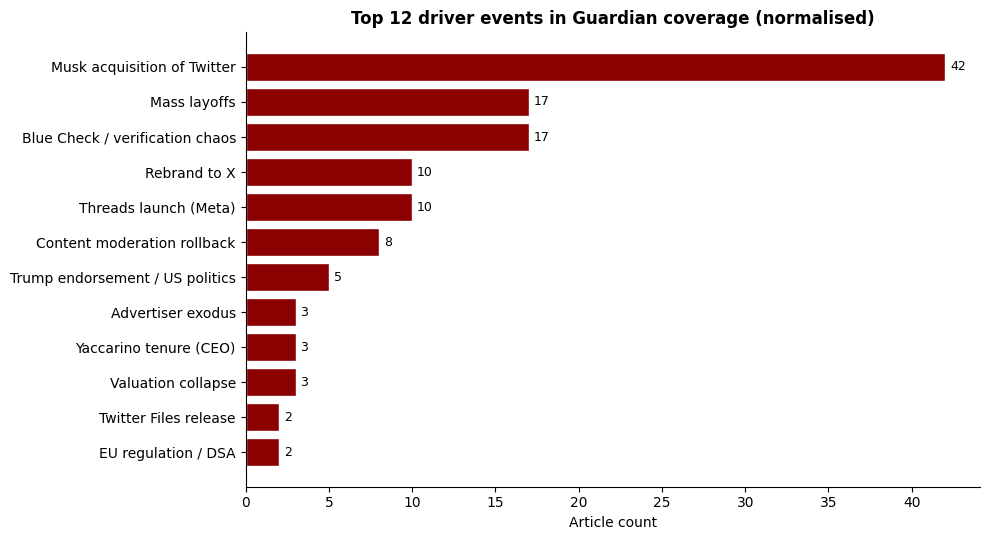

In [31]:
# =============================================================
# CHART 5 — REDRAWN with normalised driver events
# =============================================================
import matplotlib.pyplot as plt

# Exclude 'Other' from the top-12 chart so it shows real events
top_drivers = (results["driver_canonical"]
               .dropna()
               .loc[results["driver_canonical"] != "Other"]
               .value_counts()
               .head(12)
               .reset_index())
top_drivers.columns = ["driver", "count"]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(top_drivers["driver"], top_drivers["count"],
               color="#8B0000", edgecolor="white")
ax.invert_yaxis()
ax.set_title("Top 12 driver events in Guardian coverage (normalised)")
ax.set_xlabel("Article count")
for bar, count in zip(bars, top_drivers["count"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(count), va="center", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("05_top_drivers_normalised.png", dpi=150, bbox_inches="tight")
plt.show()